<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day19_practice1_%ED%8C%A8%EC%B9%98_%EC%9E%84%EB%B2%A0%EB%94%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 패치 임베딩 - 이미지를 '단어들'로 만든다

In [1]:
from torch._C import device
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
# 셀 1. 데이터 - F-MNIST
def load_fmnist(root="./data", train=True):
  tf = transforms.ToTensor() # 이미지(0-255) → 텐서(0-1)
  return datasets.FashionMNIST(root=root, train=train, transform=tf, download=True)

data = load_fmnist()
img, label = data[0]
print("\n이미지:", tuple(img.shape),"| 클래스:", data.classes[label])

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 272kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.18MB/s]


이미지: (1, 28, 28) | 클래스: Ankle boot



패치화: (1,1,28,28) → (1, 16, 49)


<function matplotlib.pyplot.show(close=None, block=None)>

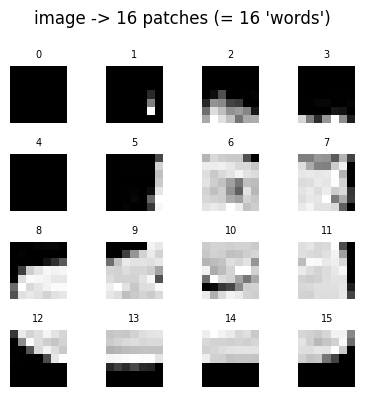

In [5]:
# 셀 2. 패치 자르기 - 28x28 을 7x7 짜리 16조각으로
PATCH = 7            # 패치 한 번 (7픽셀)
N_SIDE = 28 // PATCH # 한 줄에 4개 → 총 4x4=16개

def to_patches(images):
  B = images.shape[0]
  p = images.unfold(2, PATCH, PATCH).unfold(3, PATCH, PATCH) # (B,1,)
  # unfold(2, PATCH, PATCH) 2번째축을 PATCH 크기로 PATCH 간격으로 슬라이딩해 조각냄, 세로28을 7씩 4조각
  # unfold(3, PATCH, PATCH) 가로28을 7씩 4조각
  return p.reshape(B, N_SIDE * N_SIDE, PATCH * PATCH)

patches = to_patches(img.unsqueeze(0)) # img: (1,28,28) -> (1,1,28,28)
print(f"\n패치화: (1,1,28,28) → {tuple(patches.shape)}")

fig, axes = plt.subplots(N_SIDE, N_SIDE, figsize=(4,4))
for i, ax in enumerate(axes.flat):
  ax.imshow(patches[0,i].reshape(PATCH,PATCH), cmap="gray")
  ax.set_title(str(i), fontsize=7); ax.axis("off")
plt.suptitle("image -> 16 patches (= 16 'words')")
plt.tight_layout(); plt.savefig("plot_patches.png")
plt.show


In [7]:
# 셀 3. 패치 임베딩 - Linear 하나면 '단어 벡터'가 된다
DIM = 64
patch_embed = nn.Linear(PATCH * PATCH, DIM) # (40->64)
tokens = patch_embed(patches) # (1,16,49) -> (1,16,64) 각 패치 49픽셀 -> 64차원 토큰
print(f"\n패치 임베딩: {tuple(patches.shape)} -> {tuple(tokens.shape)}")

# 언어: 단어 번호 → nn.Embedding(표에서 꺼냄) → (B, 문장길이, 64)
# ViT : 패치 픽셀 → nn.Linear(곱해서 변환)   → (B, 패치수, 64)


패치 임베딩: (1, 16, 49) -> (1, 16, 64)


In [9]:
# 셀 4. [CLS] 와 위치
# [CLS] 토큰: '문장 요약 담당' 특수 토큰을 맨 앞에 하나 추가, 어텐션을 거치며 모든 패치의 정보를 모아 오고,
# 분류는 이 [CLS] 자리의 최종 벡터 하나로 한다
cls_token = nn.Parameter(torch.zeros(1, 1, DIM)) # (1B, 1토큰, 64벡터) 학습되는 벡터 1개
x = torch.cat((cls_token.expand(1,-1,-1), tokens), dim=1) # (1,1,64)*(1,16,64) → (1,17,64) dim=1(토큰 축)으로 이어붙이니 토큰 개수 17개
print(x[0,0]) # (1,17,64) 0번 CLS, 1-16패치
print(x[0,16]) # 마지막 패치
print(f"[CLS] 추가: (1,16,64) → {tuple(x.shape)}  ← 17토큰")

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       grad_fn=<SelectBackward0>)
tensor([ 0.5941, -0.1287, -0.7960,  0.0029, -0.3290, -0.3987, -0.1895, -0.3286,
        -0.2105,  0.0106, -0.0082,  0.3473, -0.3499, -0.2945,  0.0333,  0.4145,
        -0.2248, -0.1749,  0.2918, -0.5230, -0.2281,  0.0105, -0.0022, -0.0675,
        -0.1975,  0.2293,  0.2220, -0.0137, -0.0140,  0.0630, -0.2184,  0.3039,
         0.0684, -0.1087,  0.3066, -0.0839,  0.0030,  0.0707,  0.2651, -0.3075,
         0.0864, -0.3849,  0.0694,  0.9018, -0.0582,  0.0715,  0.0566, -0.5043,
         0.5795,  0.0506,  0.2172, -0.1470,  0.2606, -0.0238, -0.7798,  0.2571,
         0.4493,  0.1788, -0.0179,  0.1182,  0.4367, -0.1959,  0.4497,  0.0951],
       grad_fn=<SelectBackward0>)
[CLS] 추가: 

In [10]:
# 셀 5. 위치 임베딩
pos_embed = nn.Parameter(torch.zeros(1,17,DIM)) # 17자리 각각의 위치 벡터
x = x + pos_embed
print(x.shape, x)

torch.Size([1, 17, 64]) tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0594, -0.0502,  0.0436,  ..., -0.0874,  0.1180,  0.0035],
         [ 0.0604, -0.0487,  0.0447,  ..., -0.0881,  0.1182,  0.0029],
         ...,
         [ 0.3237, -0.4186, -1.1877,  ..., -0.2862,  0.3251,  0.1074],
         [ 0.4427, -0.4416, -1.1696,  ..., -0.3836,  0.3010,  0.2128],
         [ 0.5941, -0.1287, -0.7960,  ..., -0.1959,  0.4497,  0.0951]]],
       grad_fn=<AddBackward0>)
